# Replicación de la Tabla 1 y Tabla 2
## Rendimiento de Carteras Walk-Forward Fuera de Muestra

Este notebook replica la **Tabla 1** (métricas de rendimiento walk-forward) y la **Tabla 2** (ratios de Sharpe OOS agregados) del paper QHRP.

**Estrategias comparadas:**
- HRP Cuántico
- HRP Clásico
- HRP basado en Kernel
- Markowitz (varianza inversa)
- Pesos Iguales (1/N)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time
import pickle
from joblib import Parallel, delayed

# Añadir RiskLabAI al path
sys.path.insert(0, os.path.abspath("../../repos/RiskLabAI.py"))
from RiskLabAI.optimization import hrp, recursive_bisection

# Añadir módulo local quantum_hrp
sys.path.insert(0, os.path.abspath("../qhrp_figure3_4"))
from src.quantum_hrp import (
    compute_financial_features,
    average_density_matrix,
    compute_distance_matrix,
    quantum_ordering,
    classical_hrp_ordering,
    frobenius_distance,
    sharpe_ratio,
    probabilistic_sharpe_ratio,
    min_track_record_length,
    markowitz_weights,
    equal_weights,
    quasi_diagonal,
    distance_corr,
    gaussian_mmd_distance,
    compute_kernel_distance_matrix,
    kernel_based_hrp_ordering,
)

print("Todas las importaciones OK")


Todas las importaciones OK


In [2]:
# ── Configuración ──────────────────────────────────────────────────────────
DATA_DIR = os.path.abspath("../../data")
OUT_DIR  = os.path.abspath("../../latex/img")
CACHE_DIR = os.path.abspath("./cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  MODO TEST RÁPIDO: poner a True para ejecutar solo unas pocas         │
# │  ventanas primero, verificar corrección, luego poner a False           │
# │  para la ejecución completa.                                           │
# └─────────────────────────────────────────────────────────────────────────┘
QUICK_TEST      = False    # Solo 18 ventanas en total — no es necesario test rápido
QUICK_N_WINDOWS = 10       # número de ventanas en modo test rápido

# Parámetros walk-forward (según el paper)
TRAINING_WINDOW = 756   # ~3 años de días de negociación
TEST_WINDOW     = 21    # ~1 mes
ALPHA           = 2.0   # parámetro del mapa de features cuántico
P_FEATURES      = 6     # número de features (6 features financieras por paso temporal)
RF              = 0.01  # tasa libre de riesgo anual
TARGET_SR       = 0     # Sharpe de referencia para PSR
CONFIDENCE      = 0.95  # nivel de confianza para MinTRL

# Paralelización
N_JOBS = -1  # usar todos los núcleos de CPU (-1), o fijar un número

print(f"Ventana de entrenamiento: {TRAINING_WINDOW} días")
print(f"Ventana de test:          {TEST_WINDOW} días")
print(f"Features:                 P={P_FEATURES}")
if QUICK_TEST:
    print(f"Test rápido:             ACTIVADO ({QUICK_N_WINDOWS} ventanas)")
else:
    print(f"Test rápido:             DESACTIVADO (ejecución completa)")
print(f"Paralelización:          {N_JOBS} núcleos")


Ventana de entrenamiento: 756 días
Ventana de test:          21 días
Features:                 P=6
Test rápido:             DESACTIVADO (ejecución completa)
Paralelización:          -1 núcleos


In [3]:
# ── Cargar datos precalculados (pipeline exacto del paper desde prepare_data.py) ──
# features.npy shape: (N, T, P=6) — calculadas con compute_financial_features
# returns.csv shape:  (T, N)      — dropna(how='any') global sobre todos los tickers
# Esto coincide exactamente con el pipeline fetch_stock_data del paper.

features_all = np.load(os.path.join(DATA_DIR, "features.npy"))    # (N, T, 6)
returns_df   = pd.read_csv(os.path.join(DATA_DIR, "returns.csv"),
                           index_col=0, parse_dates=True)
tickers_df   = pd.read_csv(os.path.join(DATA_DIR, "tickers.csv"))

# Manejar NaN en features (las estadísticas móviles en t=0 producen NaN)
features_all = np.nan_to_num(features_all, nan=0.0)

R = returns_df.values                   # (T, N)
T_total, N = R.shape
ticker_names = tickers_df["ticker"].tolist()

print(f"Features cargadas: {features_all.shape}  →  (N={N}, T={T_total}, P={features_all.shape[2]})")
print(f"Returns cargados:  {returns_df.shape}     →  (T={T_total}, N={N})")
print(f"Rango de fechas: {returns_df.index.min().date()} → {returns_df.index.max().date()}")
print(f"Tickers: {ticker_names[:10]} ... ({N} en total)")


Features cargadas: (169, 1147, 6)  →  (N=169, T=1147, P=6)
Returns cargados:  (1147, 169)     →  (T=1147, N=169)
Rango de fechas: 2021-11-11 → 2024-12-31
Tickers: ['SPY', 'QQQ', 'DIA', 'IWM', 'IVV', 'VTI', 'VOO', 'EFA', 'EEM', 'VEA'] ... (169 en total)


In [4]:
# ── Funciones auxiliares ───────────────────────────────────────────────────
import pickle
from joblib import Parallel, delayed

def hrp_recursive_bisection(cov, sorted_items):
    """Calcula los pesos HRP mediante bisección recursiva."""
    cov_df = pd.DataFrame(cov)
    return recursive_bisection(cov_df, sorted_items)

def compute_density_for_asset(feat, alpha):
    """Calcula la matriz de densidad promedio para un activo (paralelizable)."""
    return average_density_matrix(feat, alpha)

def compute_all_densities_parallel(training_features, alpha, n_jobs):
    """Calcula las matrices de densidad para los N activos en paralelo."""
    rho_list = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(compute_density_for_asset)(feat, alpha)
        for feat in training_features
    )
    return rho_list

def save_checkpoint(results, w, path):
    """Guarda resultados parciales en disco."""
    with open(path, "wb") as f:
        pickle.dump({"results": results, "last_window": w}, f)

def load_checkpoint(path):
    """Carga resultados parciales desde disco."""
    if os.path.exists(path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        return data["results"], data["last_window"]
    return None, -1

print("Funciones auxiliares definidas.")


Funciones auxiliares definidas.


In [6]:
# ── Análisis Walk-Forward Fuera de Muestra ────────────────────────────────
CHECKPOINT_PATH = os.path.join(CACHE_DIR, "walkforward_checkpoint.pkl")

num_windows_total = (T_total - TRAINING_WINDOW) // TEST_WINDOW
num_windows = QUICK_N_WINDOWS if QUICK_TEST else num_windows_total
print(f"Total de ventanas posibles: {num_windows_total}")
print(f"Ejecutando: {num_windows} ventanas {'(TEST RÁPIDO)' if QUICK_TEST else '(EJECUCIÓN COMPLETA)'}")
print(f"Activos: N={N} (fijos en todas las ventanas)")

# Intentar reanudar desde checkpoint (solo para ejecuciones completas)
METHODS = ["HRP Cuántico", "HRP Clásico", "HRP Kernel", "Markowitz", "Pesos Iguales"]
TIMING_KEYS = ["quantum_density", "quantum_distance", "quantum_ordering",
               "classical_ordering", "kernel_ordering", "covariance_weights"]
start_window = 0
if not QUICK_TEST:
    cached_results, last_w = load_checkpoint(CHECKPOINT_PATH)
    if cached_results is not None and last_w >= 0:
        results = cached_results
        # Recuperar timings del checkpoint si existen
        timings = results.pop("__timings__", {k: [] for k in TIMING_KEYS})
        start_window = last_w + 1
        print(f"▶ Reanudando desde la ventana {start_window} (checkpoint encontrado)")
    else:
        results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}
        timings = {k: [] for k in TIMING_KEYS}
else:
    results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}
    timings = {k: [] for k in TIMING_KEYS}

t0_total = _time.time()
last_completed = start_window - 1

for w in range(start_window, num_windows):
    t0_win = _time.time()

    train_start = w * TEST_WINDOW
    train_end   = train_start + TRAINING_WINDOW
    test_start  = train_end
    test_end    = test_start + TEST_WINDOW
    if test_end > T_total:
        break

    # Extraer arrays de entrenamiento/test (todos los N activos, sin NaN en estos datos)
    training_returns = R[train_start:train_end, :]    # (756, N)
    testing_returns  = R[test_start:test_end, :]      # (21, N)

    # Extraer features precalculadas para la ventana de entrenamiento
    # features_all shape: (N, T, 6) → para cada activo i, cortar [train_start:train_end]
    training_features = [features_all[i, train_start:train_end, :] for i in range(N)]

    # ── Ordenación HRP Cuántica (cálculo de densidad paralelizado) ──
    t_step = _time.perf_counter()
    avg_rho_list = compute_all_densities_parallel(training_features, ALPHA, N_JOBS)
    timings["quantum_density"].append(_time.perf_counter() - t_step)

    t_step = _time.perf_counter()
    D_quantum = compute_distance_matrix(avg_rho_list)
    timings["quantum_distance"].append(_time.perf_counter() - t_step)

    t_step = _time.perf_counter()
    q_order = quantum_ordering(D_quantum)
    timings["quantum_ordering"].append(_time.perf_counter() - t_step)

    # ── Ordenación HRP Clásica ──
    t_step = _time.perf_counter()
    classical_order = classical_hrp_ordering(training_returns)
    timings["classical_ordering"].append(_time.perf_counter() - t_step)

    # ── Ordenación HRP basada en Kernel ──
    t_step = _time.perf_counter()
    kernel_order = kernel_based_hrp_ordering(training_features, sigma=1.0)
    timings["kernel_ordering"].append(_time.perf_counter() - t_step)

    # ── Covarianza y pesos ──
    t_step = _time.perf_counter()
    cov = np.cov(training_returns, rowvar=False)

    w_qhrp      = hrp_recursive_bisection(cov, list(q_order)).sort_index().values
    w_classical = pd.Series(hrp_recursive_bisection(cov, list(classical_order))).sort_index().values
    w_kernel    = hrp_recursive_bisection(cov, list(kernel_order)).sort_index().values
    w_marko     = markowitz_weights(cov)
    w_equal     = equal_weights(N)
    timings["covariance_weights"].append(_time.perf_counter() - t_step)

    # Normalizar
    for ww in [w_qhrp, w_classical, w_kernel, w_marko, w_equal]:
        ww /= ww.sum()

    weights_map = {
        "HRP Cuántico": w_qhrp, "HRP Clásico": w_classical,
        "HRP Kernel": w_kernel, "Markowitz": w_marko, "Pesos Iguales": w_equal,
    }

    for method, w_vec in weights_map.items():
        port_ret = testing_returns.dot(w_vec)
        sr_val, psr_val, _, _ = probabilistic_sharpe_ratio(
            port_ret, TARGET_SR, rf=RF, annualization_factor=252
        )
        results[method]["sr"].append(sr_val)
        results[method]["psr"].append(psr_val)
        results[method]["oos_returns"].extend(port_ret.tolist())
        if "HRP" in method:
            trl_val = min_track_record_length(port_ret, TARGET_SR, CONFIDENCE)
            results[method]["trl"].append(trl_val)

    # ── Progreso ──
    dt_win = _time.time() - t0_win
    elapsed = _time.time() - t0_total
    remaining_wins = num_windows - (w + 1)
    avg_per_win = elapsed / (w - start_window + 1)
    eta = remaining_wins * avg_per_win

    t_q = timings["quantum_density"][-1] + timings["quantum_distance"][-1] + timings["quantum_ordering"][-1]
    t_c = timings["classical_ordering"][-1]
    t_k = timings["kernel_ordering"][-1]

    print(
        f"  [{w+1:>4d}/{num_windows}]  "
        f"N={N}  |  ventana: {dt_win:.1f}s  |  transcurrido: {elapsed:.0f}s  |  "
        f"ETA: {eta/60:.1f}min  |  "
        f"t_Q={t_q:.1f}s  t_C={t_c:.2f}s  t_K={t_k:.2f}s  |  "
        f"SR(Q)={results['HRP Cuántico']['sr'][-1]:.2f}  "
        f"SR(C)={results['HRP Clásico']['sr'][-1]:.2f}"
    )

    last_completed = w

    # ── Checkpoint cada 5 ventanas (solo ejecución completa) ──
    if not QUICK_TEST and (w + 1) % 5 == 0:
        checkpoint_data = {**results, "__timings__": timings}
        save_checkpoint(checkpoint_data, w, CHECKPOINT_PATH)

# Guardado final
if not QUICK_TEST and last_completed >= 0:
    checkpoint_data = {**results, "__timings__": timings}
    save_checkpoint(checkpoint_data, last_completed, CHECKPOINT_PATH)
    print(f"\n✓ Checkpoint guardado en {CHECKPOINT_PATH}")

elapsed_total = _time.time() - t0_total
n_wins = len(results[METHODS[0]]["sr"])
print(f"\nWalk-forward completado: {n_wins} ventanas en {elapsed_total:.1f}s ({elapsed_total/60:.1f}min)")

Total de ventanas posibles: 18
Ejecutando: 18 ventanas (EJECUCIÓN COMPLETA)
Activos: N=169 (fijos en todas las ventanas)
▶ Reanudando desde la ventana 18 (checkpoint encontrado)

✓ Checkpoint guardado en /home/iker/TFG/src/results/cache/walkforward_checkpoint.pkl

Walk-forward completado: 18 ventanas en 0.0s (0.0min)


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# TABLA 1 — Rendimiento Walk-Forward (estadísticas por ventana)
# ══════════════════════════════════════════════════════════════════════════
table1_rows = []
for m in METHODS:
    sr_arr  = np.array(results[m]["sr"])
    psr_arr = np.array(results[m]["psr"])
    table1_rows.append({
        "Método":        m,
        "Sharpe Medio":  f"{np.mean(sr_arr):.4f}",
        "Sharpe Desv.":  f"{np.std(sr_arr):.4f}",
        "PSR Medio":     f"{np.mean(psr_arr):.4f}",
    })

table1 = pd.DataFrame(table1_rows).set_index("Método")
n_wins = len(results[METHODS[0]]["sr"])
print(f"Tabla 1 — Rendimiento Walk-Forward (Fuera de Muestra) [{n_wins} ventanas]")
print("=" * 60)
print(table1.to_string())
print()
display(table1.style.set_caption(f"Tabla 1 — Rendimiento Walk-Forward ({n_wins} ventanas)"))

Tabla 1 — Rendimiento Walk-Forward (Fuera de Muestra) [18 ventanas]
              Sharpe Medio Sharpe Desv. PSR Medio
Método                                           
HRP Cuántico        1.5016       3.7837    0.6191
HRP Clásico         1.2754       3.9986    0.5976
HRP Kernel          1.2928       3.7140    0.6054
Markowitz           1.3449       3.7788    0.6089
Pesos Iguales       1.5076       3.9906    0.6113



,Sharpe Medio,Sharpe Desv.,PSR Medio
Método,,,
HRP Cuántico,1.5016,3.7837,0.6191
HRP Clásico,1.2754,3.9986,0.5976
HRP Kernel,1.2928,3.7140,0.6054
Markowitz,1.3449,3.7788,0.6089
Pesos Iguales,1.5076,3.9906,0.6113


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# TABLA 2 — Ratio de Sharpe Agregado Fuera de Muestra
# ══════════════════════════════════════════════════════════════════════════
table2_rows = []
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sr = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)
    table2_rows.append({
        "Método":                   m,
        "Sharpe OOS Agregado":      f"{agg_sr:.4f}",
    })

table2 = pd.DataFrame(table2_rows).set_index("Método")
print(f"Tabla 2 — Ratio de Sharpe Agregado Fuera de Muestra [{n_wins} ventanas]")
print("=" * 60)
print(table2.to_string())
print()
display(table2.style.set_caption(f"Tabla 2 — Ratio de Sharpe OOS Agregado ({n_wins} ventanas)"))

Tabla 2 — Ratio de Sharpe Agregado Fuera de Muestra [18 ventanas]
              Sharpe OOS Agregado
Método                           
HRP Cuántico               1.4441
HRP Clásico                1.2378
HRP Kernel                 1.1803
Markowitz                  1.2518
Pesos Iguales              1.3193



,Sharpe OOS Agregado
Método,
HRP Cuántico,1.4441
HRP Clásico,1.2378
HRP Kernel,1.1803
Markowitz,1.2518
Pesos Iguales,1.3193


In [8]:
# ══════════════════════════════════════════════════════════════════════════
# Adicional: MinTRL para los métodos HRP
# ══════════════════════════════════════════════════════════════════════════
print("Longitud Mínima de Historial (MinTRL) promedio:")
for m in ["HRP Cuántico", "HRP Clásico", "HRP Kernel"]:
    trl_arr = np.array(results[m]["trl"])
    # Filtrar valores infinitos para el cálculo de la media
    trl_finite = trl_arr[np.isfinite(trl_arr)]
    if len(trl_finite) > 0:
        print(f"  {m}: {np.mean(trl_finite):.4f} observaciones ({len(trl_finite)}/{len(trl_arr)} finitas)")
    else:
        print(f"  {m}: todas infinitas")

Longitud Mínima de Historial (MinTRL) promedio:
  HRP Cuántico: 20.7366 observaciones (12/18 finitas)
  HRP Clásico: 410.8921 observaciones (11/18 finitas)
  HRP Kernel: 3.5794 observaciones (11/18 finitas)


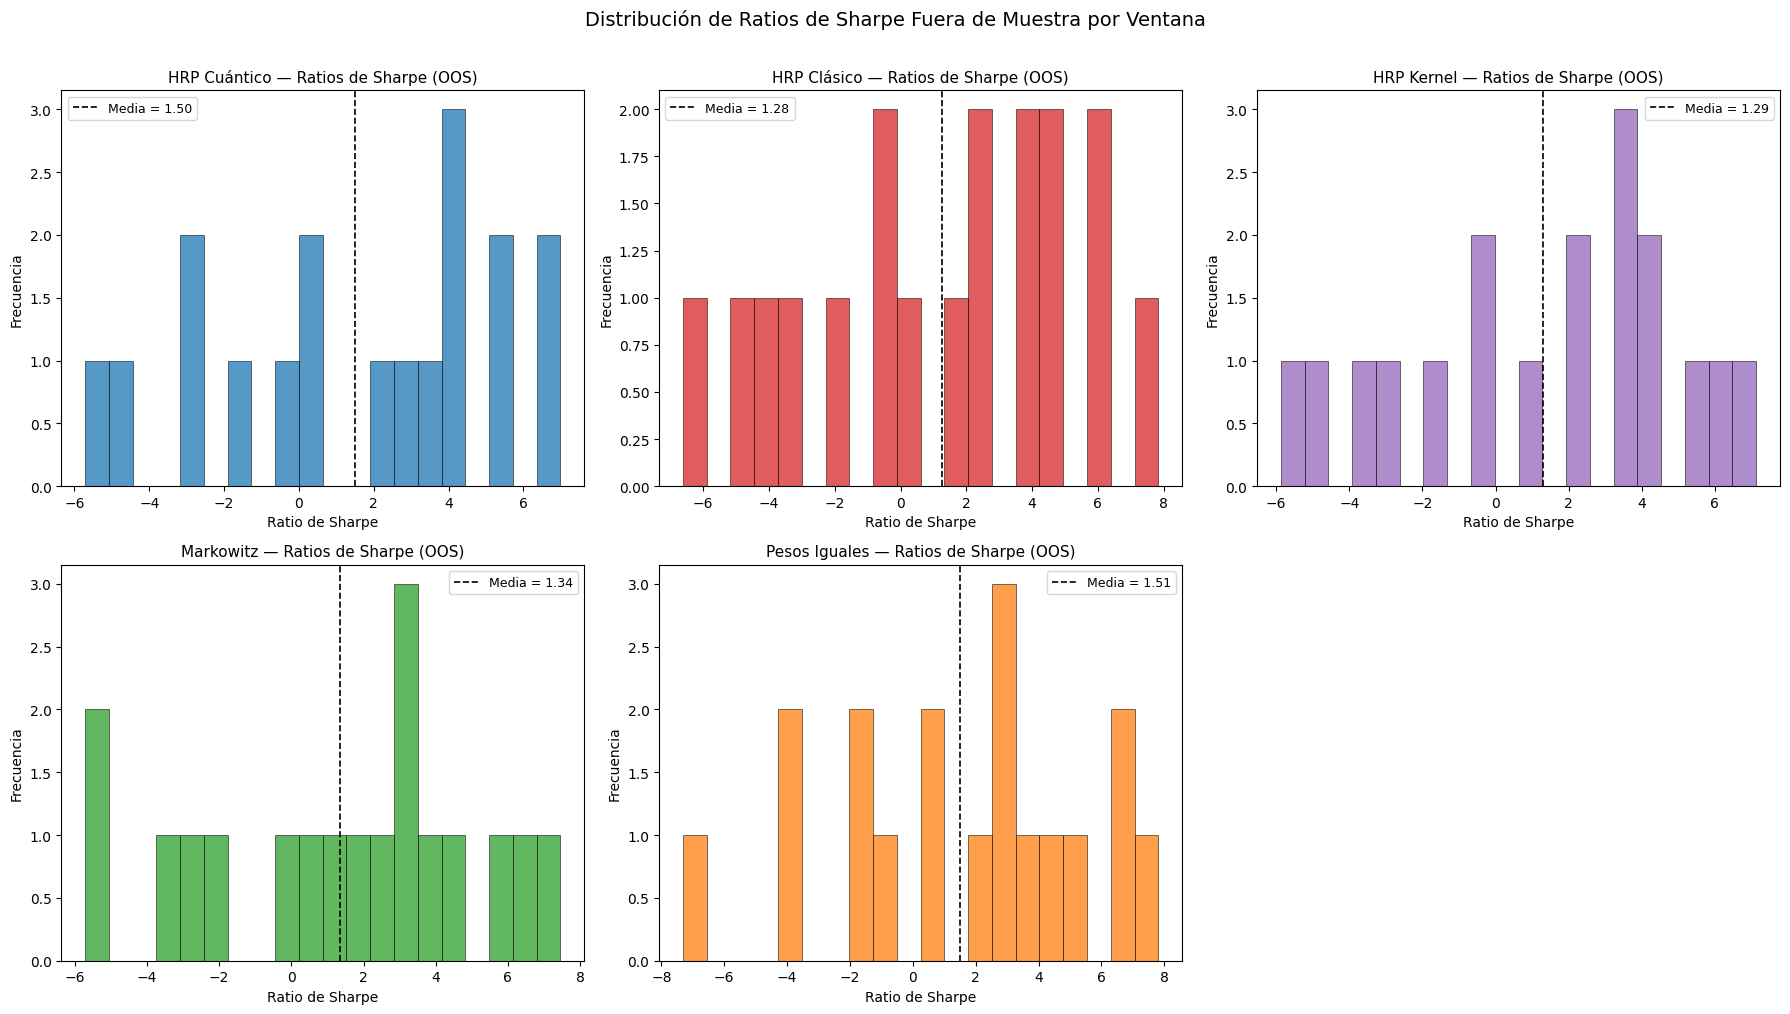

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# Histogramas de ratios de Sharpe por ventana (Figura 5 del paper)
# ══════════════════════════════════════════════════════════════════════════
colors = {
    "HRP Cuántico":  "tab:blue",
    "HRP Clásico":   "tab:red",
    "HRP Kernel":    "tab:purple",
    "Markowitz":     "tab:green",
    "Pesos Iguales": "tab:orange",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    sr_arr = np.array(results[m]["sr"])
    ax.hist(sr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(sr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Media = {np.mean(sr_arr):.2f}")
    ax.set_title(f"{m} — Ratios de Sharpe (OOS)", fontsize=11)
    ax.set_xlabel("Ratio de Sharpe")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

# Desactivar el último subplot (no usado)
axes_flat[-1].set_visible(False)

plt.suptitle("Distribución de Ratios de Sharpe Fuera de Muestra por Ventana", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-sharpe-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

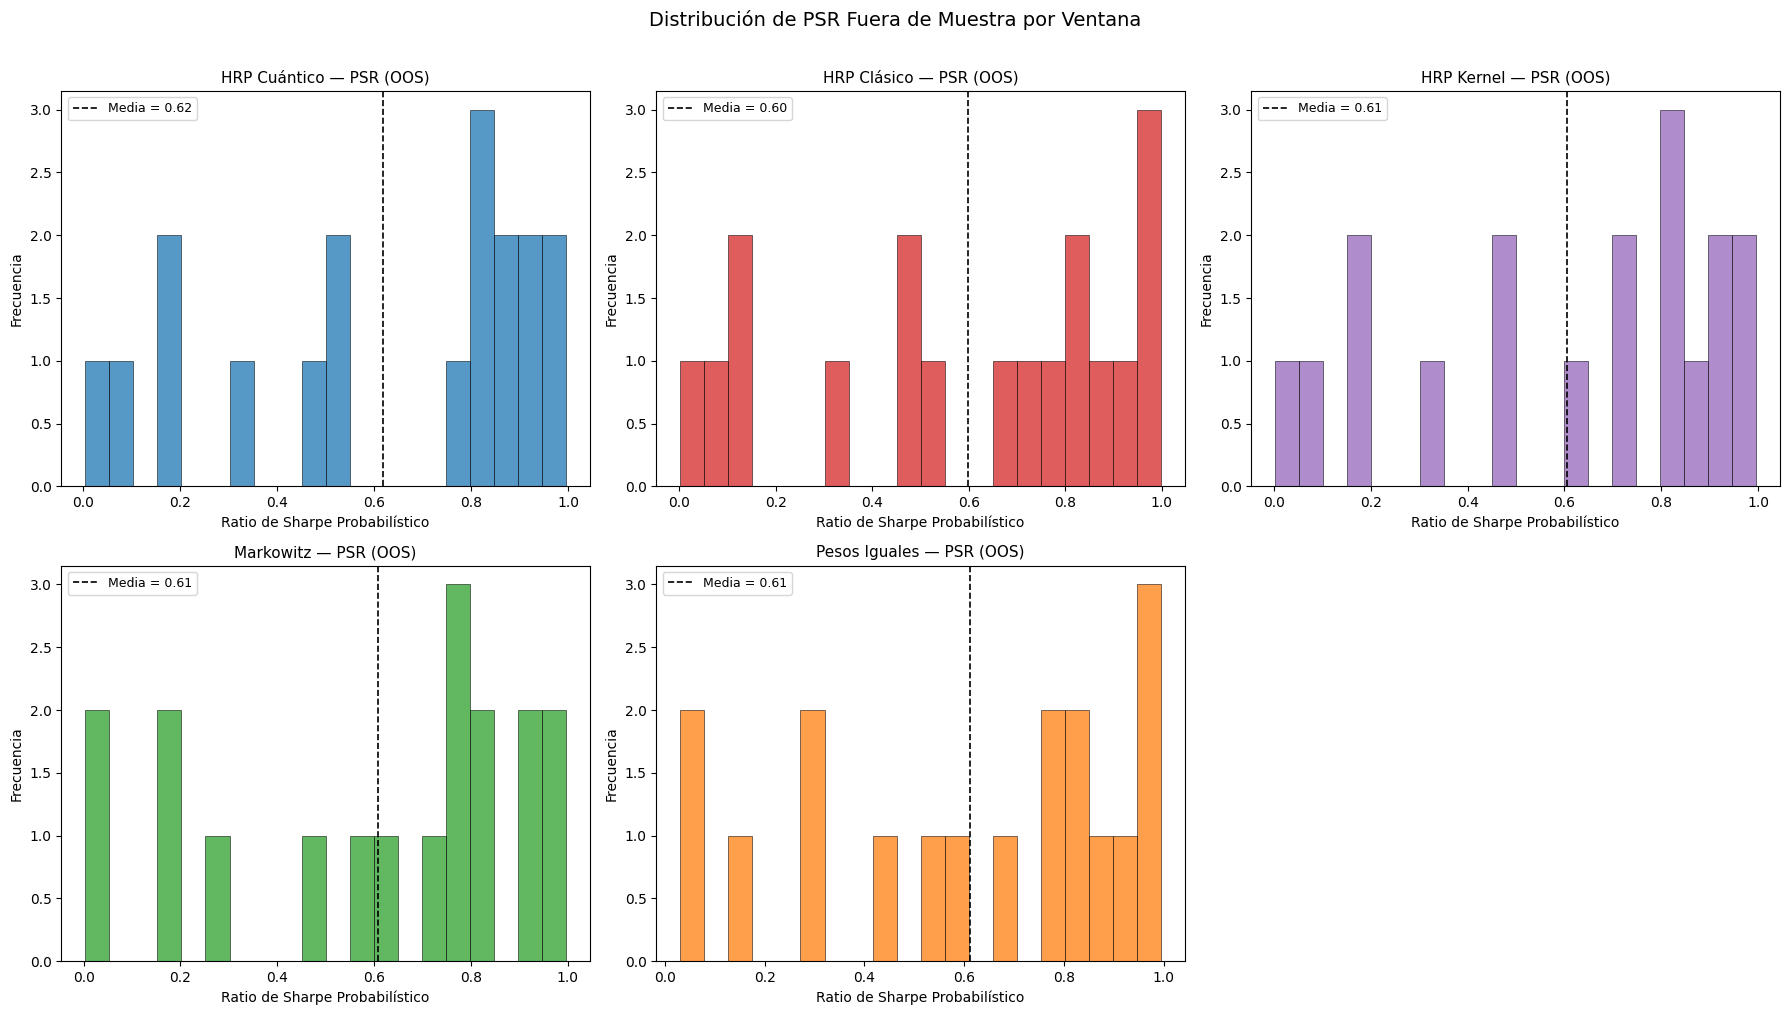

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# Histogramas de PSR por ventana
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    psr_arr = np.array(results[m]["psr"])
    ax.hist(psr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(psr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Media = {np.mean(psr_arr):.2f}")
    ax.set_title(f"{m} — PSR (OOS)", fontsize=11)
    ax.set_xlabel("Ratio de Sharpe Probabilístico")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

axes_flat[-1].set_visible(False)

plt.suptitle("Distribución de PSR Fuera de Muestra por Ventana", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-psr-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

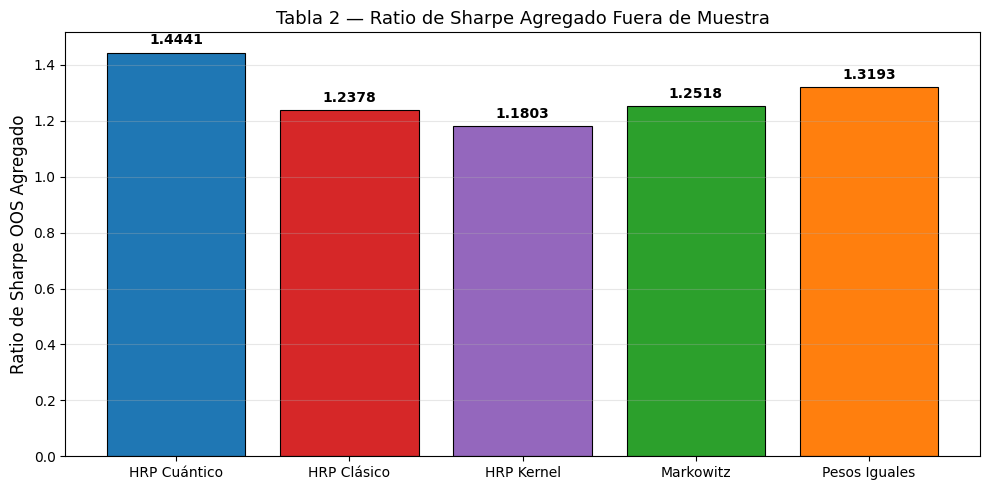

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# Gráfico de barras comparativo — Tabla 2 (Sharpe Agregado)
# ══════════════════════════════════════════════════════════════════════════
agg_sharpes = {}
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sharpes[m] = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    agg_sharpes.keys(), agg_sharpes.values(),
    color=[colors[m] for m in METHODS],
    edgecolor="black", linewidth=0.8
)
for bar, val in zip(bars, agg_sharpes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Ratio de Sharpe OOS Agregado", fontsize=12)
ax.set_title("Tabla 2 — Ratio de Sharpe Agregado Fuera de Muestra", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table2-aggregated-sharpe.png"), dpi=300, bbox_inches="tight")
plt.show()

## Tabla 3 — Coste Computacional por Método

Desglose del tiempo de ejecución medio por ventana walk-forward para cada etapa del pipeline:
- **Matrices densidad**: Simulación de circuitos cuánticos (N×T ejecuciones de circuito de P qubits)
- **Distancia cuántica**: Cálculo de la matriz de distancias de Frobenius N×N
- **Ordenación cuántica**: Clustering jerárquico (Ward) sobre distancias cuánticas
- **Ordenación clásica**: Correlación → distancia → clustering (single linkage)
- **Ordenación kernel**: MMD gaussiano → distancia → clustering (single linkage)
- **Covarianza y pesos**: Cov + bisección recursiva + Markowitz + pesos iguales

In [9]:
# ══════════════════════════════════════════════════════════════════════════
# TABLA 3 — Coste Computacional por Método (tiempos medios por ventana)
# ══════════════════════════════════════════════════════════════════════════
timing_labels = {
    "quantum_density":   "Matrices densidad (circuitos cuánticos)",
    "quantum_distance":  "Distancia Frobenius (N×N)",
    "quantum_ordering":  "Ordenación cuántica (Ward)",
    "classical_ordering":"Ordenación clásica (correlación)",
    "kernel_ordering":   "Ordenación kernel (MMD)",
    "covariance_weights":"Covarianza y pesos (bisección + Markowitz)",
}

table3_rows = []
for key in TIMING_KEYS:
    arr = np.array(timings[key])
    table3_rows.append({
        "Etapa": timing_labels[key],
        "Media (s)": f"{np.mean(arr):.3f}",
        "Desv. (s)": f"{np.std(arr):.3f}",
        "Min (s)":   f"{np.min(arr):.3f}",
        "Max (s)":   f"{np.max(arr):.3f}",
    })

# Totales por método completo
t_quantum_total = np.array(timings["quantum_density"]) + np.array(timings["quantum_distance"]) + np.array(timings["quantum_ordering"])
t_classical_total = np.array(timings["classical_ordering"])
t_kernel_total = np.array(timings["kernel_ordering"])

table3_rows.append({"Etapa": "─" * 40, "Media (s)": "─" * 8, "Desv. (s)": "─" * 8, "Min (s)": "─" * 8, "Max (s)": "─" * 8})
table3_rows.append({"Etapa": "TOTAL HRP Cuántico", "Media (s)": f"{np.mean(t_quantum_total):.3f}", "Desv. (s)": f"{np.std(t_quantum_total):.3f}", "Min (s)": f"{np.min(t_quantum_total):.3f}", "Max (s)": f"{np.max(t_quantum_total):.3f}"})
table3_rows.append({"Etapa": "TOTAL HRP Clásico",  "Media (s)": f"{np.mean(t_classical_total):.3f}", "Desv. (s)": f"{np.std(t_classical_total):.3f}", "Min (s)": f"{np.min(t_classical_total):.3f}", "Max (s)": f"{np.max(t_classical_total):.3f}"})
table3_rows.append({"Etapa": "TOTAL HRP Kernel",   "Media (s)": f"{np.mean(t_kernel_total):.3f}", "Desv. (s)": f"{np.std(t_kernel_total):.3f}", "Min (s)": f"{np.min(t_kernel_total):.3f}", "Max (s)": f"{np.max(t_kernel_total):.3f}"})

# Ratio cuántico/clásico
ratio_qc = np.mean(t_quantum_total) / np.mean(t_classical_total) if np.mean(t_classical_total) > 0 else float('inf')

table3 = pd.DataFrame(table3_rows).set_index("Etapa")
print(f"Tabla 3 — Coste Computacional por Ventana [{len(timings['quantum_density'])} ventanas, N={N}, P=6]")
print("=" * 80)
print(table3.to_string())
print(f"\nRatio Cuántico/Clásico: {ratio_qc:.1f}x")
print()
display(table3.style.set_caption(f"Tabla 3 — Coste Computacional ({len(timings['quantum_density'])} ventanas)"))

Tabla 3 — Coste Computacional por Ventana [18 ventanas, N=169, P=6]
                                           Media (s) Desv. (s)   Min (s)   Max (s)
Etapa                                                                             
Matrices densidad (circuitos cuánticos)     1903.279   290.486  1370.502  2468.884
Distancia Frobenius (N×N)                      6.284    19.258     0.791    85.630
Ordenación cuántica (Ward)                     0.004     0.005     0.001     0.019
Ordenación clásica (correlación)               0.069     0.015     0.040     0.093
Ordenación kernel (MMD)                      510.007   119.269   328.311   810.159
Covarianza y pesos (bisección + Markowitz)     1.536     0.290     0.946     2.045
────────────────────────────────────────    ────────  ────────  ────────  ────────
TOTAL HRP Cuántico                          1909.566   291.434  1374.744  2470.883
TOTAL HRP Clásico                              0.069     0.015     0.040     0.093
TOTAL HRP Kernel   

,Media (s),Desv. (s),Min (s),Max (s)
Etapa,,,,
Matrices densidad (circuitos cuánticos),1903.279,290.486,1370.502,2468.884
Distancia Frobenius (N×N),6.284,19.258,0.791,85.630
Ordenación cuántica (Ward),0.004,0.005,0.001,0.019
Ordenación clásica (correlación),0.069,0.015,0.040,0.093
Ordenación kernel (MMD),510.007,119.269,328.311,810.159
Covarianza y pesos (bisección + Markowitz),1.536,0.290,0.946,2.045
────────────────────────────────────────,────────,────────,────────,────────
TOTAL HRP Cuántico,1909.566,291.434,1374.744,2470.883
TOTAL HRP Clásico,0.069,0.015,0.040,0.093


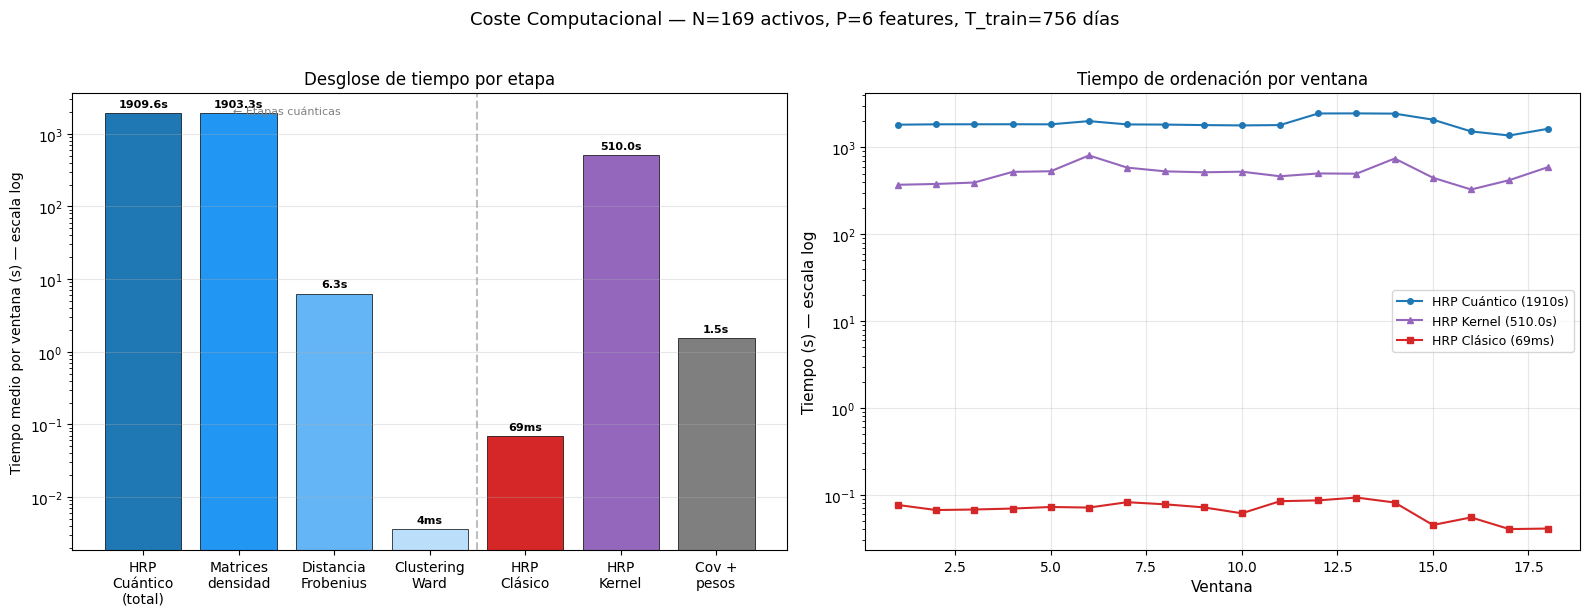


Resumen: El método cuántico es ~27643x más lento que el clásico.
El cuello de botella es la simulación de circuitos: 1903.3s de media (100% del total cuántico).


In [16]:
# ══════════════════════════════════════════════════════════════════════════
# Gráfico comparativo de tiempos por método
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel izquierdo: barras agrupadas con escala logarítmica ──
method_names = ["HRP\nCuántico\n(total)", "Matrices\ndensidad", "Distancia\nFrobenius",
                "Clustering\nWard", "HRP\nClásico", "HRP\nKernel", "Cov +\npesos"]
method_times = [
    np.mean(t_quantum_total),
    np.mean(timings["quantum_density"]),
    np.mean(timings["quantum_distance"]),
    np.mean(timings["quantum_ordering"]),
    np.mean(timings["classical_ordering"]),
    np.mean(timings["kernel_ordering"]),
    np.mean(timings["covariance_weights"]),
]
bar_colors = ["tab:blue", "#2196F3", "#64B5F6", "#BBDEFB", "tab:red", "tab:purple", "tab:gray"]

bars = axes[0].bar(method_names, method_times, color=bar_colors, edgecolor="black", linewidth=0.5)

# Añadir etiquetas de valor sobre cada barra
for bar, val in zip(bars, method_times):
    if val >= 1:
        label = f"{val:.1f}s"
    else:
        label = f"{val*1000:.0f}ms"
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                 label, ha="center", va="bottom", fontsize=8, fontweight="bold")

axes[0].set_yscale("log")
axes[0].set_ylabel("Tiempo medio por ventana (s) — escala log", fontsize=10)
axes[0].set_title("Desglose de tiempo por etapa", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)
# Separador visual entre etapas cuánticas y el resto
axes[0].axvline(x=3.5, color="gray", linestyle="--", alpha=0.5)
axes[0].text(1.5, axes[0].get_ylim()[1] * 0.5, "← Etapas cuánticas", fontsize=8, color="gray", ha="center")

# ── Panel derecho: evolución del tiempo por ventana (log) ──
wins = range(1, len(timings["quantum_density"]) + 1)
axes[1].plot(wins, t_quantum_total, "o-", color="tab:blue", markersize=4, label=f"HRP Cuántico ({np.mean(t_quantum_total):.0f}s)")
axes[1].plot(wins, t_kernel_total, "^-", color="tab:purple", markersize=4, label=f"HRP Kernel ({np.mean(t_kernel_total):.1f}s)")
axes[1].plot(wins, t_classical_total, "s-", color="tab:red", markersize=4, label=f"HRP Clásico ({np.mean(t_classical_total)*1000:.0f}ms)")
axes[1].set_yscale("log")
axes[1].set_xlabel("Ventana", fontsize=11)
axes[1].set_ylabel("Tiempo (s) — escala log", fontsize=11)
axes[1].set_title("Tiempo de ordenación por ventana", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Coste Computacional — N={N} activos, P=6 features, T_train={TRAINING_WINDOW} días", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "tabla3-tiempos-computacionales.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "tabla3-tiempos-computacionales.pdf"), bbox_inches="tight")
plt.show()

print(f"\nResumen: El método cuántico es ~{ratio_qc:.0f}x más lento que el clásico.")
print(f"El cuello de botella es la simulación de circuitos: {np.mean(timings['quantum_density']):.1f}s de media "
      f"({np.mean(timings['quantum_density'])/np.mean(t_quantum_total)*100:.0f}% del total cuántico).")